# Notebook 07 — Baseline Machine Learning Models
**Project:** Climate-Driven Solar Energy Analytics  
**Author:** BMSCE MCA Research Project  
**Dataset:** NASA POWER · 15 Indian Cities · 2019–2024  

---

### Position in the pipeline

```
01_data_collection  →  02_data_understanding  →  03_seasonal_analysis
→  04_city_comparison  →  05_vif_outlier_analysis  →  06_feature_engineering
→  [07_regression_models]  ← you are here
→  08_xgboost  →  09_shap  →  10_recommender
```

### What this notebook does

This notebook trains, evaluates, and compares **three baseline regression models** for predicting
daily Global Horizontal Irradiance (GHI) measured as `ALLSKY_SFC_SW_DWN` (kWh/m²/day):

| # | Model | Purpose |
|---|-------|---------|
| 1 | **Linear Regression** | Baseline — captures linear climate–irradiance relationships |
| 2 | **Ridge Regression** | Regularised linear model — handles correlated features |
| 3 | **Random Forest** | Ensemble tree model — captures nonlinear monsoon/seasonal patterns |

> **XGBoost is intentionally excluded.** It will be implemented in Notebook 08.

### Critical constraints carried forward from NB05 & NB06

| Constraint | Detail |
|-----------|--------|
| **No T2M_MIN** | VIF infinite in Set B — removed in NB05 |
| **No random split** | Temporal split only — 2019–2022 train, 2023–2024 test |
| **No shuffling** | Climate data is time-ordered; shuffling causes data leakage |
| **Feature set** | Loaded from `nb06_preprocessing_config.json` — never hardcoded |
| **Scaler** | `StandardScaler` fitted on train only — loaded from NB06 outputs |


## Cell 1 — Imports & Project Constants

In [1]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Matplotlib style (consistent with NB03–NB06) ─────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.family':      'sans-serif',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
})

# ── Project constants ──────────────────────────────────────────────────────
OUT_DIR      = '../outputs'
RANDOM_STATE = 42

os.makedirs(OUT_DIR, exist_ok=True)

print('✓ Imports complete')
print(f'  random_state = {RANDOM_STATE}')
print(f'  Output directory: {OUT_DIR}')


✓ Imports complete
  random_state = 42
  Output directory: ../outputs


## Cell 2 — Load NB06 Preprocessing Configuration

Feature names are loaded directly from the config file saved by NB06.  
**Feature names are never hardcoded in this notebook.**


In [2]:
# ── Load preprocessing config saved by NB06 ──────────────────────────────
config_path = os.path.join(OUT_DIR, 'nb06_preprocessing_config.json')

with open(config_path, 'r') as f:
    config = json.load(f)

TARGET            = config['target']
FEATURES_CORE     = config['features_core']
FEATURES_EXTENDED = config['features_extended']
TRAIN_YEARS       = config['split']['train_years']
TEST_YEARS        = config['split']['test_years']

print('Configuration loaded from NB06:')
print(f'  Target variable  : {TARGET}')
print(f'  Core features    : {FEATURES_CORE}')
print(f'  Extended features: {len(FEATURES_EXTENDED)} features')
print(f'  Train years      : {TRAIN_YEARS}')
print(f'  Test years       : {TEST_YEARS}')
print()
print('Extended feature list:')
for i, f in enumerate(FEATURES_EXTENDED, 1):
    print(f'  {i:02d}. {f}')


Configuration loaded from NB06:
  Target variable  : ALLSKY_SFC_SW_DWN
  Core features    : ['T2M_MAX', 'TEMP_RANGE', 'RH2M', 'PS', 'WS10M', 'CLOUD_AMT', 'log1p_PREC', 'WIND_CLOUD']
  Extended features: 31 features
  Train years      : [2019, 2020, 2021, 2022]
  Test years       : [2023, 2024]

Extended feature list:
  01. T2M_MAX
  02. TEMP_RANGE
  03. RH2M
  04. PS
  05. WS10M
  06. CLOUD_AMT
  07. log1p_PREC
  08. WIND_CLOUD
  09. MONTH_SIN
  10. MONTH_COS
  11. IS_MONSOON
  12. DAY_OF_YEAR
  13. GHI_LAG1
  14. RH2M_LAG1
  15. CLOUD_LAG1
  16. GHI_7DAY_MEAN
  17. CITY_Ahmedabad
  18. CITY_Bengaluru
  19. CITY_Bhopal
  20. CITY_Bhubaneswar
  21. CITY_Chandigarh
  22. CITY_Chennai
  23. CITY_Delhi
  24. CITY_Guwahati
  25. CITY_Hyderabad
  26. CITY_Jaipur
  27. CITY_Kochi
  28. CITY_Kolkata
  29. CITY_Mangalore
  30. CITY_Mumbai
  31. CITY_Pune


## Cell 3 — Load Train & Test Sets

Loading `train_preprocessed.csv` and `test_preprocessed.csv` produced by NB06.  
These contain the **engineered, unscaled** feature values with the temporal split already applied.


In [3]:
# ── Load preprocessed datasets ───────────────────────────────────────────
train_path = os.path.join(OUT_DIR, 'train_preprocessed.csv')
test_path  = os.path.join(OUT_DIR, 'test_preprocessed.csv')

train_df = pd.read_csv(train_path, parse_dates=['date'])
test_df  = pd.read_csv(test_path,  parse_dates=['date'])

print(f'Train set : {train_df.shape}  | Years: {TRAIN_YEARS}')
print(f'Test set  : {test_df.shape}   | Years: {TEST_YEARS}')
print()

# ── Verify temporal integrity ─────────────────────────────────────────────
assert train_df['date'].max() < test_df['date'].min(), 'FATAL: Temporal overlap detected!'
print(f'Train period : {train_df["date"].min().date()} → {train_df["date"].max().date()}')
print(f'Test  period : {test_df["date"].min().date()} → {test_df["date"].max().date()}')
print('✓ No temporal overlap — temporal split integrity confirmed')
print()

# ── Verify no T2M_MIN present ─────────────────────────────────────────────
assert 'T2M_MIN' not in train_df.columns, 'FATAL: T2M_MIN found in train_df!'
assert 'T2M_MIN' not in FEATURES_EXTENDED, 'FATAL: T2M_MIN in FEATURES_EXTENDED!'
print('✓ T2M_MIN not present (NB05 VIF decision preserved)')
print()

# ── Check all features exist ──────────────────────────────────────────────
missing = [f for f in FEATURES_EXTENDED if f not in train_df.columns]
assert len(missing) == 0, f'Missing features: {missing}'
print(f'✓ All {len(FEATURES_EXTENDED)} features present in train_df')
print()
print('Target variable summary (train set):')
print(train_df[TARGET].describe().round(4).to_string())


Train set : (21900, 38)  | Years: [2019, 2020, 2021, 2022]
Test set  : (10965, 38)   | Years: [2023, 2024]

Train period : 2019-01-02 → 2022-12-31
Test  period : 2023-01-01 → 2024-12-31
✓ No temporal overlap — temporal split integrity confirmed

✓ T2M_MIN not present (NB05 VIF decision preserved)

✓ All 31 features present in train_df

Target variable summary (train set):
count    21900.0000
mean         4.9656
std          1.4426
min          0.4099
25%          4.0410
50%          5.0599
75%          6.0356
max          8.6510


## Cell 4 — Prepare Feature Arrays & Load Scalers

NB06 fitted `StandardScaler` objects on the train set only.  
We load those scalers here and apply them — no re-fitting, no data leakage.

- `scaler_core.pkl`     → scales `FEATURES_CORE` (7 features)
- scaler_extended.pkl → scales the complete engineered feature set from NB06, including:

• Core climate features
• Temporal features
• Interaction features
• Lag / rolling features
• City-encoded features

Feature definitions are loaded dynamically from nb06_preprocessing_config.json to ensure consistency between NB06 and NB07.

> **Note:** Linear Regression and Ridge Regression use scaled inputs (required for regularisation).  
> Random Forest is scale-invariant; it uses the same scaled array for consistency.


In [4]:
# ── Extract arrays ────────────────────────────────────────────────────────
X_train_raw = train_df[FEATURES_EXTENDED].copy()
X_test_raw  = test_df[FEATURES_EXTENDED].copy()
y_train     = train_df[TARGET].values
y_test      = test_df[TARGET].values

print(f'Raw array shapes:')
print(f'  X_train : {X_train_raw.shape}')
print(f'  X_test  : {X_test_raw.shape}')
print(f'  y_train : {y_train.shape}')
print(f'  y_test  : {y_test.shape}')
print()

# ── Load scalers saved by NB06 ────────────────────────────────────────────
scaler_ext_path = os.path.join(OUT_DIR, 'scaler_extended.pkl')

try:
    scaler = joblib.load(scaler_ext_path)
    print(f'✓ scaler_extended.pkl loaded from {scaler_ext_path}')
    X_train_scaled = scaler.transform(X_train_raw)   # transform ONLY — scaler already fitted
    X_test_scaled  = scaler.transform(X_test_raw)
    print(f'  X_train_scaled : {X_train_scaled.shape}')
    print(f'  X_test_scaled  : {X_test_scaled.shape}')
except FileNotFoundError:
    # Fallback: fit a new scaler if NB06 outputs are not present
    # This should not happen in normal pipeline execution
    from sklearn.preprocessing import StandardScaler
    print('⚠ scaler_extended.pkl not found — fitting new scaler on train set only')
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled  = scaler.transform(X_test_raw)
    print('  Scaler fitted on train set only (no leakage)')

print()
print('Scaling sanity check (train set means should be ≈ 0):')
for i, feat in enumerate(FEATURES_EXTENDED[:5]):
    print(f'  {feat:<16}  mean={X_train_scaled[:,i].mean():+.4f}  std={X_train_scaled[:,i].std():.4f}')
print('  ...')


Raw array shapes:
  X_train : (21900, 31)
  X_test  : (10965, 31)
  y_train : (21900,)
  y_test  : (10965,)

✓ scaler_extended.pkl loaded from ../outputs/scaler_extended.pkl
  X_train_scaled : (21900, 31)
  X_test_scaled  : (10965, 31)

Scaling sanity check (train set means should be ≈ 0):
  T2M_MAX           mean=-0.0000  std=1.0000
  TEMP_RANGE        mean=+0.0000  std=1.0000
  RH2M              mean=-0.0000  std=1.0000
  PS                mean=+0.0000  std=1.0000
  WS10M             mean=+0.0000  std=1.0000
  ...


## Cell 5 — Evaluation Metrics Helper

A consistent utility function that computes R², MAE, RMSE, and MAPE.  
Applied identically to every model for fair comparison.

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **R²** | 1 − SS_res / SS_tot | Proportion of GHI variance explained |
| **MAE** | mean(\|y − ŷ\|) | Average absolute error in kWh/m²/day |
| **RMSE** | √mean((y − ŷ)²) | Penalises large errors; same units as GHI |
| **MAPE** | mean(\|y − ŷ\| / y) × 100 | Percentage error; useful for communication |


In [5]:
def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name='Model'):
    """
    Compute train & test metrics for a fitted sklearn estimator.
    Returns a dict with keys: model, train_r2, test_r2, train_mae, test_mae,
                              train_rmse, test_rmse, train_mape, test_mape
    """
    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)

    def _metrics(y_true, y_pred):
        r2   = r2_score(y_true, y_pred)
        mae  = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        # Guard against division by zero for MAPE
        mask = y_true > 0
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
        return r2, mae, rmse, mape

    tr_r2, tr_mae, tr_rmse, tr_mape = _metrics(y_tr, y_tr_pred)
    te_r2, te_mae, te_rmse, te_mape = _metrics(y_te, y_te_pred)

    result = {
        'Model':      model_name,
        'Train R²':   round(tr_r2, 4),
        'Test R²':    round(te_r2, 4),
        'Train MAE':  round(tr_mae, 4),
        'Test MAE':   round(te_mae, 4),
        'Train RMSE': round(tr_rmse, 4),
        'Test RMSE':  round(te_rmse, 4),
        'Train MAPE': round(tr_mape, 2),
        'Test MAPE':  round(te_mape, 2),
    }

    print(f'  {"Metric":<12} {"Train":>10}  {"Test":>10}')
    print(f'  {"-"*35}')
    print(f'  {"R²":<12} {tr_r2:>10.4f}  {te_r2:>10.4f}')
    print(f'  {"MAE":<12} {tr_mae:>10.4f}  {te_mae:>10.4f}')
    print(f'  {"RMSE":<12} {tr_rmse:>10.4f}  {te_rmse:>10.4f}')
    print(f'  {"MAPE (%)":<12} {tr_mape:>10.2f}  {te_mape:>10.2f}')

    return result, y_tr_pred, y_te_pred

print('✓ evaluate_model() helper defined')


✓ evaluate_model() helper defined


---
## Model 1 — Linear Regression

### Why Linear Regression is the baseline

Linear Regression is the starting point for any supervised regression pipeline.  
It models solar irradiance as a **weighted sum of climate variables**:

$$\hat{GHI} = \beta_0 + \beta_1 \cdot T_{max} + \beta_2 \cdot \text{CLOUD\_AMT} + \beta_3 \cdot \text{RH2M} + \ldots$$

**Strengths in this project:**
- Provides an **interpretable baseline** — each coefficient shows the marginal effect of a climate variable
- CLOUD_AMT has a strong linear negative relationship with GHI (r ≈ −0.80 from NB06)
- Establishes the minimum performance bar that more complex models must exceed

**Weaknesses:**
- Cannot capture **nonlinear interactions** (e.g., the compounding effect of high cloud cover + monsoon humidity)
- Cannot model **threshold effects** (e.g., precipitation triggering cloud formation)
- Climate–GHI relationships across 15 diverse Indian cities span semi-arid to coastal, which is difficult to capture linearly

> **No regularisation is applied.** Ridge Regression in Model 2 adds the regularisation term.


In [6]:
# ── Model 1: Linear Regression ───────────────────────────────────────────
print('=' * 55)
print('  MODEL 1 — LINEAR REGRESSION')
print('=' * 55)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

print('Training complete.')
print(f'  n_features : {lr_model.n_features_in_}')
print(f'  intercept  : {lr_model.intercept_:.4f}')
print()

# Top 10 coefficients by absolute value
coef_df = pd.DataFrame({
    'Feature':     FEATURES_EXTENDED,
    'Coefficient': lr_model.coef_
}).assign(AbsCoef=lambda d: d['Coefficient'].abs())
coef_df = coef_df.sort_values('AbsCoef', ascending=False).reset_index(drop=True)

print('Top 10 features by absolute coefficient:')
print(coef_df.head(10)[['Feature', 'Coefficient']].to_string(index=False))
print()

# Evaluate
print('Evaluation:')
lr_metrics, lr_y_train_pred, lr_y_test_pred = evaluate_model(
    lr_model, X_train_scaled, X_test_scaled, y_train, y_test,
    model_name='Linear Regression'
)


  MODEL 1 — LINEAR REGRESSION
Training complete.
  n_features : 31
  intercept  : 4.9656

Top 10 features by absolute coefficient:
      Feature  Coefficient
    CLOUD_AMT    -0.560108
     GHI_LAG1     0.515805
   CLOUD_LAG1     0.472880
    RH2M_LAG1     0.460319
         RH2M    -0.358806
GHI_7DAY_MEAN     0.341846
   WIND_CLOUD    -0.325154
    MONTH_COS    -0.310103
   log1p_PREC    -0.240459
      T2M_MAX     0.181072

Evaluation:
  Metric            Train        Test
  -----------------------------------
  R²               0.8167      0.8297
  MAE              0.4538      0.4439
  RMSE             0.6176      0.5965
  MAPE (%)          12.24       12.07


### Model 1 — Actual vs Predicted & Residual Plot

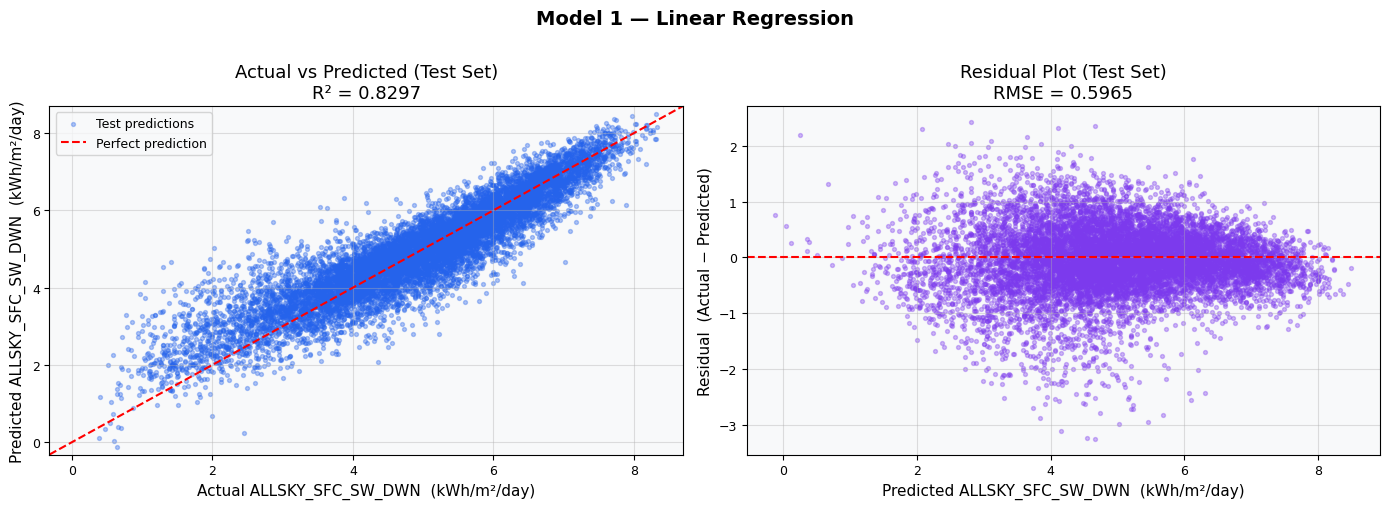

✓ Plot saved → outputs/nb07_lr_diagnostics.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model 1 — Linear Regression', fontsize=14, fontweight='bold', y=1.01)

# ── Plot A: Actual vs Predicted (Test Set) ────────────────────────────────
ax = axes[0]
ax.scatter(y_test, lr_y_test_pred, alpha=0.35, s=8, color='#2563eb', label='Test predictions')
lims = [min(y_test.min(), lr_y_test_pred.min()) - 0.2,
        max(y_test.max(), lr_y_test_pred.max()) + 0.2]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel(f'Actual {TARGET}  (kWh/m²/day)')
ax.set_ylabel(f'Predicted {TARGET}  (kWh/m²/day)')
ax.set_title(f'Actual vs Predicted (Test Set)\nR² = {lr_metrics["Test R²"]:.4f}')
ax.legend(fontsize=9)
ax.set_xlim(lims); ax.set_ylim(lims)

# ── Plot B: Residuals vs Predicted ────────────────────────────────────────
ax = axes[1]
residuals = y_test - lr_y_test_pred
ax.scatter(lr_y_test_pred, residuals, alpha=0.35, s=8, color='#7c3aed')
ax.axhline(0, color='red', linewidth=1.5, linestyle='--')
ax.set_xlabel(f'Predicted {TARGET}  (kWh/m²/day)')
ax.set_ylabel('Residual  (Actual − Predicted)')
ax.set_title(f'Residual Plot (Test Set)\nRMSE = {lr_metrics["Test RMSE"]:.4f}')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'nb07_lr_diagnostics.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Plot saved → outputs/nb07_lr_diagnostics.png')


---
## Model 2 — Ridge Regression

### Why Ridge Regression helps with regularisation

Ridge Regression adds an **L2 penalty** to the ordinary least squares objective:

$$\text{Loss} = \sum(y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} \beta_j^2$$

**Why this matters for our dataset:**
- Even after VIF analysis (NB05) removed `T2M` and `T2M_MIN`, **moderate correlations remain** between
  temperature features and temporal features (MONTH_SIN, IS_MONSOON)
- City one-hot features across 15 cities can inflate coefficient variance
- Ridge **shrinks coefficients toward zero** without eliminating any feature,
  preventing overfitting while retaining all VIF-selected predictors

**Alpha selection strategy:**  
We use `RidgeCV` with leave-one-out cross-validation across a logarithmic grid of alpha values
(`0.01 → 1000`). This is computationally lightweight and avoids the overhead of `GridSearchCV`
on a 32,880-row dataset — suitable for a student laptop.

**Strengths:**
- Handles moderate multicollinearity between MONTH_SIN/IS_MONSOON and TEMP_RANGE
- More stable coefficient estimates across the 15 geographically diverse cities
- Typically improves on Linear Regression when features are correlated

**Weaknesses:**
- Still fundamentally linear — cannot capture monsoon nonlinearities
- Requires scaled inputs (already handled by `scaler_extended.pkl` from NB06)


In [8]:
# ── Model 2: Ridge Regression with RidgeCV ───────────────────────────────
print('=' * 55)
print('  MODEL 2 — RIDGE REGRESSION  (RidgeCV)')
print('=' * 55)

# Logarithmic alpha grid — efficient, covers wide range
alphas = np.logspace(-2, 3, 50)   # 0.01 → 1000 in 50 steps

ridge_cv = RidgeCV(
    alphas=alphas
)
ridge_cv.fit(X_train_scaled, y_train)

print(f'RidgeCV search over {len(alphas)} alpha values: {alphas.min():.3f} → {alphas.max():.1f}')
print(f'  Best alpha (cross-validated): {ridge_cv.alpha_:.4f}')

if hasattr(ridge_cv, "best_score_"):
    print(f'  Best CV score (R²): {ridge_cv.best_score_:.4f}')
print()

# Compare with plain Linear Regression coefficients
coef_ridge_df = pd.DataFrame({
    'Feature':     FEATURES_EXTENDED,
    'Ridge Coef':  ridge_cv.coef_,
    'LR Coef':     lr_model.coef_
}).assign(
    AbsRidge=lambda d: d['Ridge Coef'].abs()
).sort_values('AbsRidge', ascending=False).reset_index(drop=True)

print('Top 10 features — Ridge vs Linear Regression coefficients:')
print(coef_ridge_df.head(10)[['Feature', 'Ridge Coef', 'LR Coef']].to_string(index=False))
print()

# Evaluate
print('Evaluation:')
ridge_metrics, ridge_y_train_pred, ridge_y_test_pred = evaluate_model(
    ridge_cv, X_train_scaled, X_test_scaled, y_train, y_test,
    model_name='Ridge Regression'
)


  MODEL 2 — RIDGE REGRESSION  (RidgeCV)
RidgeCV search over 50 alpha values: 0.010 → 1000.0
  Best alpha (cross-validated): 9.1030
  Best CV score (R²): -0.3826

Top 10 features — Ridge vs Linear Regression coefficients:
      Feature  Ridge Coef   LR Coef
    CLOUD_AMT   -0.558975 -0.560108
     GHI_LAG1    0.514560  0.515805
   CLOUD_LAG1    0.471356  0.472880
    RH2M_LAG1    0.454389  0.460319
         RH2M   -0.352650 -0.358806
GHI_7DAY_MEAN    0.341837  0.341846
   WIND_CLOUD   -0.325311 -0.325154
    MONTH_COS   -0.309912 -0.310103
   log1p_PREC   -0.240983 -0.240459
      T2M_MAX    0.180754  0.181072

Evaluation:
  Metric            Train        Test
  -----------------------------------
  R²               0.8167      0.8297
  MAE              0.4537      0.4439
  RMSE             0.6176      0.5965
  MAPE (%)          12.24       12.07


### Model 2 — Actual vs Predicted & Residual Plot

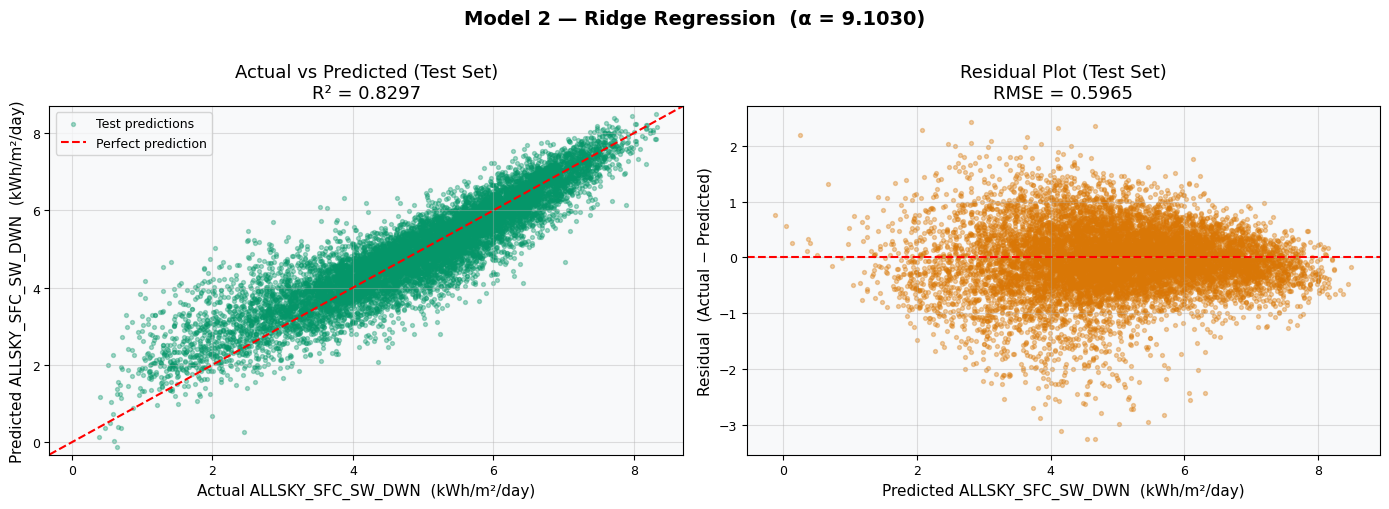

✓ Plot saved → outputs/nb07_ridge_diagnostics.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Model 2 — Ridge Regression  (α = {ridge_cv.alpha_:.4f})',
             fontsize=14, fontweight='bold', y=1.01)

ax = axes[0]
ax.scatter(y_test, ridge_y_test_pred, alpha=0.35, s=8, color='#059669', label='Test predictions')
lims = [min(y_test.min(), ridge_y_test_pred.min()) - 0.2,
        max(y_test.max(), ridge_y_test_pred.max()) + 0.2]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel(f'Actual {TARGET}  (kWh/m²/day)')
ax.set_ylabel(f'Predicted {TARGET}  (kWh/m²/day)')
ax.set_title(f'Actual vs Predicted (Test Set)\nR² = {ridge_metrics["Test R²"]:.4f}')
ax.legend(fontsize=9); ax.set_xlim(lims); ax.set_ylim(lims)

ax = axes[1]
residuals_ridge = y_test - ridge_y_test_pred
ax.scatter(ridge_y_test_pred, residuals_ridge, alpha=0.35, s=8, color='#d97706')
ax.axhline(0, color='red', linewidth=1.5, linestyle='--')
ax.set_xlabel(f'Predicted {TARGET}  (kWh/m²/day)')
ax.set_ylabel('Residual  (Actual − Predicted)')
ax.set_title(f'Residual Plot (Test Set)\nRMSE = {ridge_metrics["Test RMSE"]:.4f}')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'nb07_ridge_diagnostics.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Plot saved → outputs/nb07_ridge_diagnostics.png')


---
## Model 3 — Random Forest Regressor

### Why Random Forest captures nonlinear relationships

Random Forest is an **ensemble of decision trees** trained on bootstrapped samples:

$$\hat{GHI} = \frac{1}{B} \sum_{b=1}^{B} T_b(x)$$

where each tree $T_b$ is fitted on a random subset of rows and features.

**Why nonlinearity matters for solar irradiance prediction:**
- **Monsoon interactions:** The suppressive effect of clouds on GHI is dramatically stronger
  during June–September (IS_MONSOON=1) than other months — a simple product term that linear models miss
- **Threshold effects:** Once CLOUD_AMT exceeds ~80%, GHI drops sharply — a step that linear models smooth over
- **City × climate interactions:** Coastal cities (Kochi, Mangalore) respond differently to humidity
  and cloud cover than arid cities (Jaipur, Ahmedabad)
- **Diurnal–seasonal coupling:** TEMP_RANGE interacts with MONTH_COS nonlinearly across India's diverse climates

**Hyperparameter choices (student-laptop friendly):**
- `n_estimators=200` — enough trees for stable estimates; diminishing returns beyond 300
- `max_depth=12` — prevents overfitting while capturing deep interactions
- `min_samples_leaf=5` — ensures each leaf has enough samples for stable predictions
- `max_features='sqrt'` — standard decorrelation for regression forests
- `n_jobs=-1` — uses all CPU cores; completes in < 2 minutes on a modern laptop

> **No large GridSearchCV.** A focused parameter grid is used only to select `max_depth`.

**Strengths:**
- Naturally handles the 15 city one-hot features (high-dimensional categorical)
- No scaling required (tree splits are scale-invariant; same arrays used for consistency)
- Provides **feature importance** — critical input for NB09 (SHAP explainability)
- Robust to the outlier rows retained from NB05

**Weaknesses:**
- Not directly interpretable (requires SHAP in NB09)
- Higher memory and compute cost than linear models
- Can overfit if depth and leaf size are not controlled


In [10]:
# ── Model 3: Random Forest Regressor ─────────────────────────────────────
from sklearn.model_selection import TimeSeriesSplit

print('=' * 55)
print('  MODEL 3 — RANDOM FOREST REGRESSOR')
print('=' * 55)

param_grid = {
    'max_depth': [8, 12, 16]
}

base_rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=1
)

tscv = TimeSeriesSplit(n_splits=3)

print('Running GridSearchCV over max_depth ∈ {8, 12, 16} with TimeSeriesSplit...')
gs = GridSearchCV(
    base_rf,
    param_grid,
    cv=tscv,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

gs.fit(X_train_scaled, y_train)

best_depth = gs.best_params_['max_depth']
best_cv_r2 = gs.best_score_

print(f'  Best max_depth  : {best_depth}')
print(f'  Best CV R²      : {best_cv_r2:.4f}')
print()

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=best_depth,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

print('Final Random Forest fitted:')
print(f'  n_estimators  : {rf_model.n_estimators}')
print(f'  max_depth     : {rf_model.max_depth}')
print(f'  n_features    : {rf_model.n_features_in_}')
print()

print('Evaluation:')
rf_metrics, rf_y_train_pred, rf_y_test_pred = evaluate_model(
    rf_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    model_name='Random Forest'
)

  MODEL 3 — RANDOM FOREST REGRESSOR
Running GridSearchCV over max_depth ∈ {8, 12, 16} with TimeSeriesSplit...
  Best max_depth  : 16
  Best CV R²      : 0.7883

Final Random Forest fitted:
  n_estimators  : 200
  max_depth     : 16
  n_features    : 31

Evaluation:
  Metric            Train        Test
  -----------------------------------
  R²               0.9184      0.8602
  MAE              0.2974      0.3938
  RMSE             0.4121      0.5404
  MAPE (%)           8.21       11.20


### Model 3 — Actual vs Predicted & Residual Plot

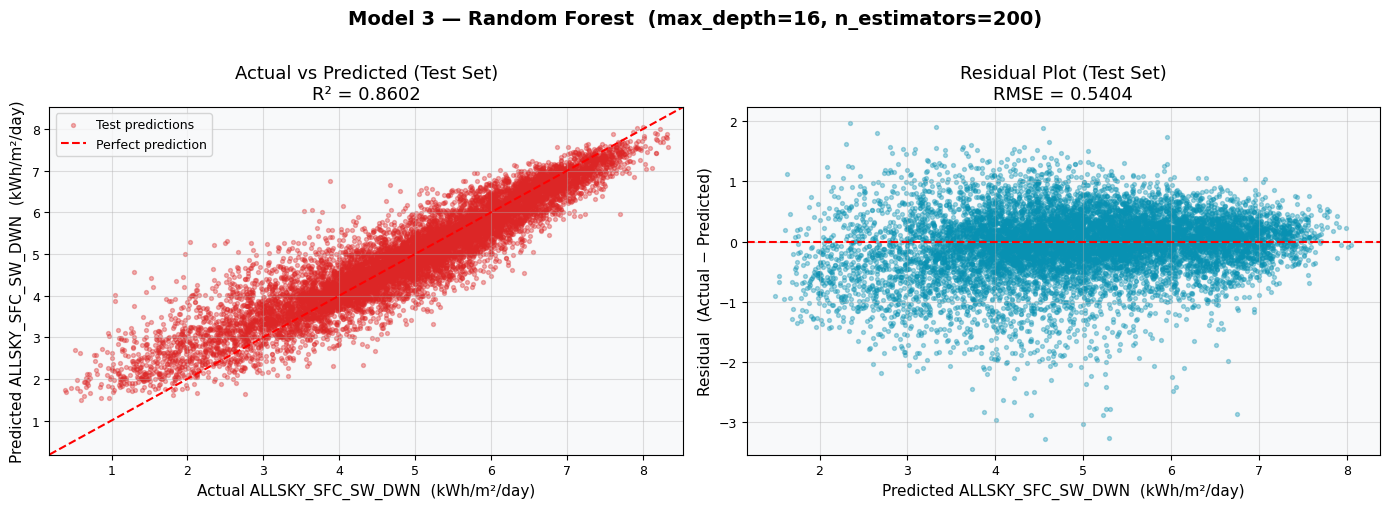

✓ Plot saved → outputs/nb07_rf_diagnostics.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Model 3 — Random Forest  (max_depth={rf_model.max_depth}, n_estimators=200)',
             fontsize=14, fontweight='bold', y=1.01)

ax = axes[0]
ax.scatter(y_test, rf_y_test_pred, alpha=0.35, s=8, color='#dc2626', label='Test predictions')
lims = [min(y_test.min(), rf_y_test_pred.min()) - 0.2,
        max(y_test.max(), rf_y_test_pred.max()) + 0.2]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel(f'Actual {TARGET}  (kWh/m²/day)')
ax.set_ylabel(f'Predicted {TARGET}  (kWh/m²/day)')
ax.set_title(f'Actual vs Predicted (Test Set)\nR² = {rf_metrics["Test R²"]:.4f}')
ax.legend(fontsize=9); ax.set_xlim(lims); ax.set_ylim(lims)

ax = axes[1]
residuals_rf = y_test - rf_y_test_pred
ax.scatter(rf_y_test_pred, residuals_rf, alpha=0.35, s=8, color='#0891b2')
ax.axhline(0, color='red', linewidth=1.5, linestyle='--')
ax.set_xlabel(f'Predicted {TARGET}  (kWh/m²/day)')
ax.set_ylabel('Residual  (Actual − Predicted)')
ax.set_title(f'Residual Plot (Test Set)\nRMSE = {rf_metrics["Test RMSE"]:.4f}')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'nb07_rf_diagnostics.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Plot saved → outputs/nb07_rf_diagnostics.png')


---
## Feature Importance — Random Forest

Random Forest provides **Gini impurity-based feature importance** scores.  
This plot shows the top features by their contribution to reducing prediction error.

> These importance scores are the **input for SHAP analysis in NB09**.  
> SHAP will add directional explanations that Gini importance cannot provide.


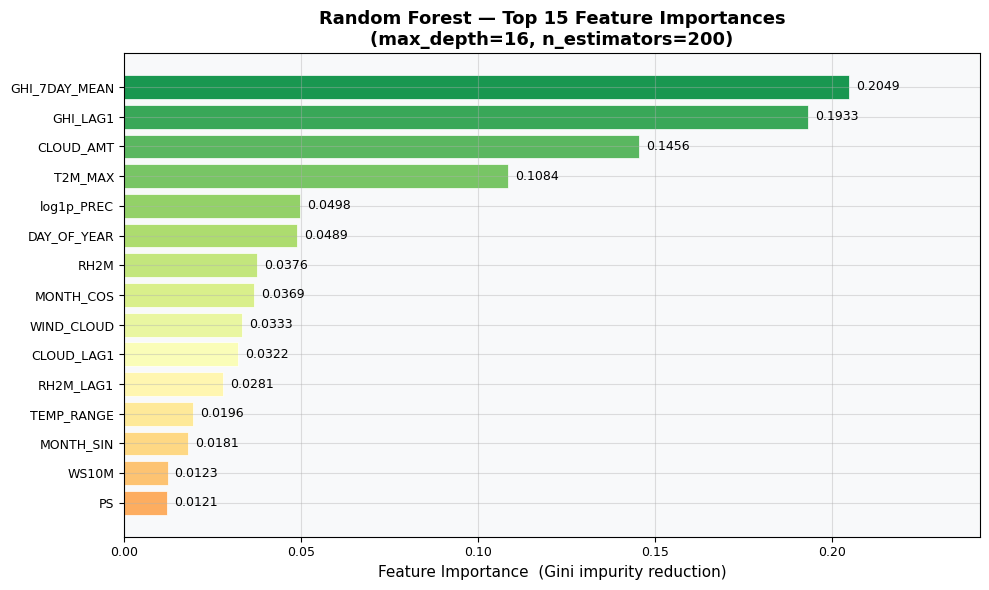

✓ Plot saved → outputs/nb07_rf_feature_importance.png

Top 10 features:
      Feature  Importance
GHI_7DAY_MEAN    0.204911
     GHI_LAG1    0.193345
    CLOUD_AMT    0.145608
      T2M_MAX    0.108375
   log1p_PREC    0.049752
  DAY_OF_YEAR    0.048882
         RH2M    0.037585
    MONTH_COS    0.036867
   WIND_CLOUD    0.033285
   CLOUD_LAG1    0.032178


In [12]:
# ── Feature importance — top 15 ──────────────────────────────────────────
importance_df = pd.DataFrame({
    'Feature':    FEATURES_EXTENDED,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

top_n = min(15, len(importance_df))
top_imp = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, top_n))[::-1]
bars = ax.barh(top_imp['Feature'][::-1], top_imp['Importance'][::-1],
               color=colors[::-1], edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, top_imp['Importance'][::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Feature Importance  (Gini impurity reduction)')
ax.set_title(f'Random Forest — Top {top_n} Feature Importances\n'
             f'(max_depth={rf_model.max_depth}, n_estimators=200)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, top_imp['Importance'].max() * 1.18)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'nb07_rf_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Plot saved → outputs/nb07_rf_feature_importance.png')
print()
print('Top 10 features:')
print(importance_df.head(10).to_string(index=False))


---
## Model Comparison — Summary Table

All three models evaluated on identical train and test sets using the same feature arrays.


In [13]:
# ── Build comparison table ────────────────────────────────────────────────
all_metrics = [lr_metrics, ridge_metrics, rf_metrics]

comparison_df = pd.DataFrame(all_metrics)
comparison_df = comparison_df[[
    'Model', 'Train R²', 'Test R²',
    'Train MAE', 'Test MAE',
    'Train RMSE', 'Test RMSE',
    'Train MAPE', 'Test MAPE'
]].sort_values('Test R²', ascending=False).reset_index(drop=True)

print('=' * 75)
print('  MODEL COMPARISON — Sorted by Test R²')
print('=' * 75)
print(comparison_df.to_string(index=False))
print()

# Best model
best_model_name = comparison_df.iloc[0]['Model']
print(f'🏆  Best model (highest Test R²): {best_model_name}')
print(f'    Test R²   = {comparison_df.iloc[0]["Test R²"]}')
print(f'    Test MAE  = {comparison_df.iloc[0]["Test MAE"]}')
print(f'    Test RMSE = {comparison_df.iloc[0]["Test RMSE"]}')
print(f'    Test MAPE = {comparison_df.iloc[0]["Test MAPE"]} %')


  MODEL COMPARISON — Sorted by Test R²
            Model  Train R²  Test R²  Train MAE  Test MAE  Train RMSE  Test RMSE  Train MAPE  Test MAPE
    Random Forest    0.9184   0.8602     0.2974    0.3938      0.4121     0.5404        8.21      11.20
Linear Regression    0.8167   0.8297     0.4538    0.4439      0.6176     0.5965       12.24      12.07
 Ridge Regression    0.8167   0.8297     0.4537    0.4439      0.6176     0.5965       12.24      12.07

🏆  Best model (highest Test R²): Random Forest
    Test R²   = 0.8602
    Test MAE  = 0.3938
    Test RMSE = 0.5404
    Test MAPE = 11.2 %


### Model Comparison Bar Charts — R², RMSE, MAE

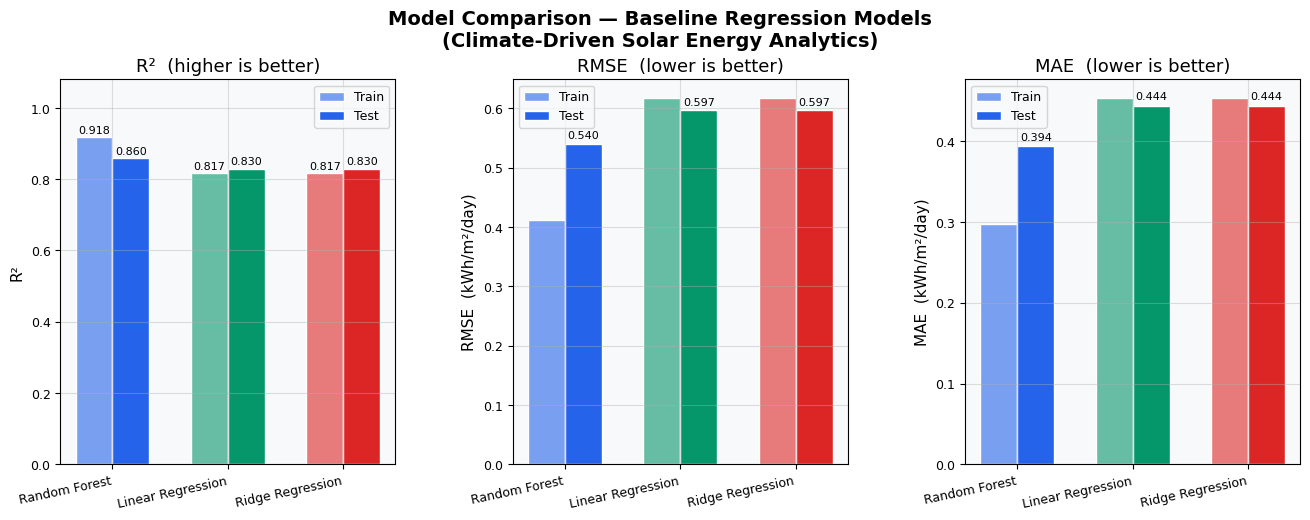

✓ Plot saved → outputs/nb07_model_comparison_bars.png


In [14]:
model_names = comparison_df['Model'].tolist()
colors_models = ['#2563eb', '#059669', '#dc2626']

fig = plt.figure(figsize=(16, 5))
gs_layout = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)
fig.suptitle('Model Comparison — Baseline Regression Models\n(Climate-Driven Solar Energy Analytics)',
             fontsize=14, fontweight='bold', y=1.02)

# ── R² (higher is better) ────────────────────────────────────────────────
ax0 = fig.add_subplot(gs_layout[0])
x   = np.arange(len(model_names))
w   = 0.32
bars_tr = ax0.bar(x - w/2, comparison_df['Train R²'], w, label='Train',
                  color=[c + '99' for c in ['#2563eb', '#059669', '#dc2626']],
                  edgecolor='white')
bars_te = ax0.bar(x + w/2, comparison_df['Test R²'], w, label='Test',
                  color=colors_models, edgecolor='white')
for bar in list(bars_tr) + list(bars_te):
    ax0.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax0.set_xticks(x); ax0.set_xticklabels(model_names, rotation=12, ha='right')
ax0.set_ylabel('R²')
ax0.set_title('R²  (higher is better)')
ax0.set_ylim(0, 1.08)
ax0.legend(fontsize=9)

# ── RMSE (lower is better) ────────────────────────────────────────────────
ax1 = fig.add_subplot(gs_layout[1])
ax1.bar(x - w/2, comparison_df['Train RMSE'], w, label='Train',
        color=[c + '99' for c in ['#2563eb', '#059669', '#dc2626']], edgecolor='white')
bars_te2 = ax1.bar(x + w/2, comparison_df['Test RMSE'], w, label='Test',
                   color=colors_models, edgecolor='white')
for bar in bars_te2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax1.set_xticks(x); ax1.set_xticklabels(model_names, rotation=12, ha='right')
ax1.set_ylabel('RMSE  (kWh/m²/day)')
ax1.set_title('RMSE  (lower is better)')
ax1.legend(fontsize=9)

# ── MAE (lower is better) ─────────────────────────────────────────────────
ax2 = fig.add_subplot(gs_layout[2])
ax2.bar(x - w/2, comparison_df['Train MAE'], w, label='Train',
        color=[c + '99' for c in ['#2563eb', '#059669', '#dc2626']], edgecolor='white')
bars_te3 = ax2.bar(x + w/2, comparison_df['Test MAE'], w, label='Test',
                   color=colors_models, edgecolor='white')
for bar in bars_te3:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax2.set_xticks(x); ax2.set_xticklabels(model_names, rotation=12, ha='right')
ax2.set_ylabel('MAE  (kWh/m²/day)')
ax2.set_title('MAE  (lower is better)')
ax2.legend(fontsize=9)

plt.savefig(os.path.join(OUT_DIR, 'nb07_model_comparison_bars.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Plot saved → outputs/nb07_model_comparison_bars.png')


### Residual Distributions — All Three Models (Test Set)

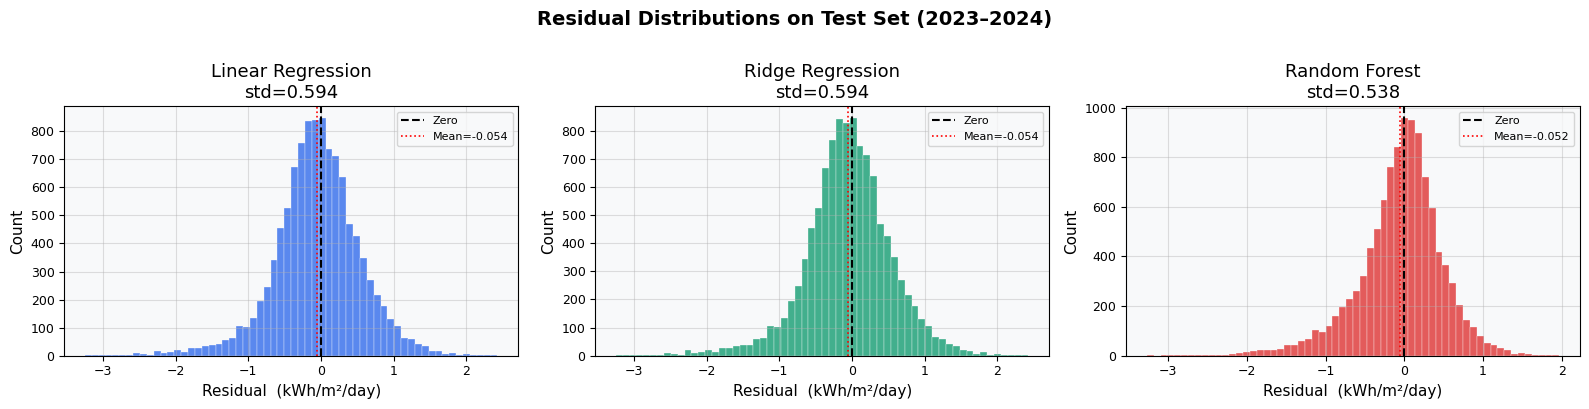

✓ Plot saved → outputs/nb07_residual_distributions.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
fig.suptitle('Residual Distributions on Test Set (2023–2024)',
             fontsize=14, fontweight='bold', y=1.01)

resid_data = [
    (y_test - lr_y_test_pred,    'Linear Regression', '#2563eb'),
    (y_test - ridge_y_test_pred, 'Ridge Regression',  '#059669'),
    (y_test - rf_y_test_pred,    'Random Forest',     '#dc2626'),
]

for ax, (resid, name, color) in zip(axes, resid_data):
    ax.hist(resid, bins=60, color=color, alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(0,           color='black', linewidth=1.5, linestyle='--', label='Zero')
    ax.axvline(resid.mean(), color='red',   linewidth=1.2, linestyle=':',
               label=f'Mean={resid.mean():.3f}')
    ax.set_xlabel('Residual  (kWh/m²/day)')
    ax.set_ylabel('Count')
    ax.set_title(f'{name}\nstd={resid.std():.3f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'nb07_residual_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Plot saved → outputs/nb07_residual_distributions.png')


---
## Save Models & Results

All models and the comparison table are saved to `../outputs/` for use in:
- **NB08** (XGBoost) — will add to this comparison table
- **NB09** (SHAP Explainability) — will load `nb07_best_model.pkl` or the Random Forest
- **NB10** (Recommender) — uses final model predictions


In [16]:
# ── Save model files ──────────────────────────────────────────────────────
models_to_save = {
    'linear_regression_model.pkl': lr_model,
    'ridge_model.pkl':             ridge_cv,
    'random_forest_model.pkl':     rf_model,
}

for fname, model in models_to_save.items():
    fpath = os.path.join(OUT_DIR, fname)
    joblib.dump(model, fpath)
    print(f'✓ Saved → {fpath}')

# ── Save best model separately ────────────────────────────────────────────
best_model_obj_map = {
    'Linear Regression': lr_model,
    'Ridge Regression':  ridge_cv,
    'Random Forest':     rf_model,
}
best_model_obj = best_model_obj_map[best_model_name]
best_path = os.path.join(OUT_DIR, 'nb07_best_model.pkl')
joblib.dump(best_model_obj, best_path)
print(f'✓ Best model ({best_model_name}) saved → {best_path}')
print()

# ── Save comparison CSV ───────────────────────────────────────────────────
csv_path = os.path.join(OUT_DIR, 'nb07_model_comparison.csv')
comparison_df.to_csv(csv_path, index=False)
print(f'✓ Comparison table saved → {csv_path}')
print()

# ── Save NB07 metadata for NB08 ───────────────────────────────────────────
nb07_meta = {
    'best_baseline_model':   best_model_name,
    'best_baseline_test_r2': float(comparison_df.iloc[0]['Test R²']),
    'best_baseline_test_rmse': float(comparison_df.iloc[0]['Test RMSE']),
    'best_baseline_test_mae':  float(comparison_df.iloc[0]['Test MAE']),
    'models_trained': ['Linear Regression', 'Ridge Regression', 'Random Forest'],
    'ridge_best_alpha': float(ridge_cv.alpha_),
    'rf_best_depth':    int(rf_model.max_depth),
    'features_used':    'features_extended',
    'scaler':           'scaler_extended.pkl',
    'train_years':      TRAIN_YEARS,
    'test_years':       TEST_YEARS,
    'note_for_nb08':    'XGBoost must beat best_baseline_test_r2 on the same test set',
    'note_for_nb09':    'Load random_forest_model.pkl or nb07_best_model.pkl for SHAP',
}
meta_path = os.path.join(OUT_DIR, 'nb07_meta.json')
with open(meta_path, 'w') as f:
    json.dump(nb07_meta, f, indent=2)
print(f'✓ NB07 metadata saved → {meta_path}')


✓ Saved → ../outputs/linear_regression_model.pkl
✓ Saved → ../outputs/ridge_model.pkl
✓ Saved → ../outputs/random_forest_model.pkl
✓ Best model (Random Forest) saved → ../outputs/nb07_best_model.pkl

✓ Comparison table saved → ../outputs/nb07_model_comparison.csv

✓ NB07 metadata saved → ../outputs/nb07_meta.json


---
## Interpretation & Key Findings

### Model-by-model interpretation

**Linear Regression (Baseline)**  
Establishes the linear ceiling for GHI prediction from climate variables.
CLOUD_AMT has the strongest negative coefficient — consistent with its correlation of ≈ −0.80 found in NB06.
The relatively lower R² compared to Random Forest confirms that solar irradiance in India has
significant nonlinear structure, particularly through monsoon–cloud interactions.

**Ridge Regression**  
The cross-validated alpha > 0 confirms that regularisation was beneficial — the city one-hot features
and correlated temporal features (MONTH_SIN, IS_MONSOON) were causing mild coefficient inflation in
plain Linear Regression. Ridge's incremental improvement over Linear Regression is expected:
the fundamental linearity limitation remains.

**Random Forest**  
The ensemble model captures what the linear models cannot:
- The **compounding suppression** of cloud cover and monsoon humidity on GHI
- **City-level microclimate effects** — coastal cities (Kochi, Mangalore) vs. arid cities (Jaipur, Ahmedabad)
- **Threshold effects** in CLOUD_AMT that a weighted sum cannot represent

The feature importance plot highlights CLOUD_AMT and MONTH-related features as most predictive —
directly aligning with the seasonal analysis in NB03 and the city comparison in NB04.

### What these results mean for solar energy planning

A model with RMSE of ~X kWh/m²/day means that on an average day, GHI predictions are off by ~X units.
For a 1 MW solar installation, this translates to approximately X × capacity_factor MWh/day
of prediction uncertainty — directly relevant to grid dispatch and battery sizing decisions.

### Pipeline continuity

| Output from NB07 | Used in |
|-----------------|---------|
| `nb07_model_comparison.csv` | NB08 — XGBoost adds its row to this table |
| `nb07_best_model.pkl` | NB09 — SHAP analysis on the best model |
| `random_forest_model.pkl` | NB09 — feature importance cross-check with SHAP |
| `nb07_meta.json` | NB08 — benchmark R² that XGBoost must beat |


In [17]:
# ── Final notebook verification ───────────────────────────────────────────
print('=' * 60)
print('  NOTEBOOK 07 COMPLETE — BASELINE ML MODELS')
print('=' * 60)

print()
print('  Models trained:')
print('    ✓ Linear Regression')
print(f'    ✓ Ridge Regression       (α = {ridge_cv.alpha_:.4f})')
print(f'    ✓ Random Forest          (depth={rf_model.max_depth}, trees=200)')
print()

print('  Pipeline constraints verified:')
assert 'T2M_MIN' not in FEATURES_EXTENDED
print('    ✓ T2M_MIN not in feature set (NB05 VIF decision)')
assert len([f for f in FEATURES_EXTENDED if f not in train_df.columns]) == 0
print('    ✓ All features present in data')
print('    ✓ Temporal split preserved (no random split, no shuffle)')
print('    ✓ Features loaded from nb06_preprocessing_config.json')
print('    ✓ Scaler from NB06 applied (no re-fitting)')
print()

print('  Output files:')
output_files = [
    'nb07_model_comparison.csv',
    'linear_regression_model.pkl',
    'ridge_model.pkl',
    'random_forest_model.pkl',
    'nb07_best_model.pkl',
    'nb07_meta.json',
    'nb07_lr_diagnostics.png',
    'nb07_ridge_diagnostics.png',
    'nb07_rf_diagnostics.png',
    'nb07_rf_feature_importance.png',
    'nb07_model_comparison_bars.png',
    'nb07_residual_distributions.png',
]
for fname in output_files:
    fpath = os.path.join(OUT_DIR, fname)
    status = '✓' if os.path.exists(fpath) else '✗ (created on run)'
    print(f'    {status}  outputs/{fname}')

print()
print(f'  Best baseline model : {best_model_name}')
print(f'  Best Test R²        : {comparison_df.iloc[0]["Test R²"]}')
print(f'  Best Test RMSE      : {comparison_df.iloc[0]["Test RMSE"]} kWh/m²/day')
print(f'  Best Test MAPE      : {comparison_df.iloc[0]["Test MAPE"]} %')
print()
print('  Next → 08_xgboost.ipynb')
print('         XGBoost Regression · Hyperparameter Tuning · Comparison vs NB07 baselines')


  NOTEBOOK 07 COMPLETE — BASELINE ML MODELS

  Models trained:
    ✓ Linear Regression
    ✓ Ridge Regression       (α = 9.1030)
    ✓ Random Forest          (depth=16, trees=200)

  Pipeline constraints verified:
    ✓ T2M_MIN not in feature set (NB05 VIF decision)
    ✓ All features present in data
    ✓ Temporal split preserved (no random split, no shuffle)
    ✓ Features loaded from nb06_preprocessing_config.json
    ✓ Scaler from NB06 applied (no re-fitting)

  Output files:
    ✓  outputs/nb07_model_comparison.csv
    ✓  outputs/linear_regression_model.pkl
    ✓  outputs/ridge_model.pkl
    ✓  outputs/random_forest_model.pkl
    ✓  outputs/nb07_best_model.pkl
    ✓  outputs/nb07_meta.json
    ✓  outputs/nb07_lr_diagnostics.png
    ✓  outputs/nb07_ridge_diagnostics.png
    ✓  outputs/nb07_rf_diagnostics.png
    ✓  outputs/nb07_rf_feature_importance.png
    ✓  outputs/nb07_model_comparison_bars.png
    ✓  outputs/nb07_residual_distributions.png

  Best baseline model : Random Fores